# HW1

Submit via [form](https://forms.gle/vtc3kDX2soNzEMU39)

**Deadline:** 10.02.20265 23:59

**Reminder:** Plagiarism is prohibited (0 for the whole assignment). The use of AI tools without indicating it is also prohibited (0 for the whole assignment).

In [183]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from zlib import adler32
from scipy.stats import ks_2samp

Let's work with network of charaters' interaction from Breaking Bad TV show:

In [184]:
df = pd.read_csv("https://raw.githubusercontent.com/jishnukoliyadan/the_breaking_bad_network/refs/heads/master/data/gephi_files/Combined.csv")
df.sample(3)

,source,target,weight,community
341,Saul Goodman,Huell Babineaux,24,7
158,Hank,Gale Boetticher,71,4
398,Brock,Todd Alquist,5,3


Let's create weighted network: set the `weight` attribute of the edges:

In [185]:
#edgelist - list of pairs of nodes that are connected by an edge (из него создаем матрицу смежности)
#nx.from_pandas_edgelist => 1) Берёт все уникальные значения из столбцов 'source' и 'target' → создаёт узлы =>
# 2) Для каждой строки создаёт ребро между source и target =>
# 3) Если указан параметр edge_attr='weight', то копирует значение веса как атрибут ребра
# G = nx.Graph() - создает пустой граф!
G = nx.from_pandas_edgelist(df, 'source', 'target', edge_attr='weight')
nx.to_numpy_array(G) # возвращаем матрицу смежности с весами


array([[  0.,  43., 847., ...,   0.,   0.,   0.],
       [ 43.,   0.,  11., ...,   0.,   0.,   0.],
       [847.,  11.,   0., ...,   0.,   0.,   0.],
       ...,
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.]])

Let's draw the network:

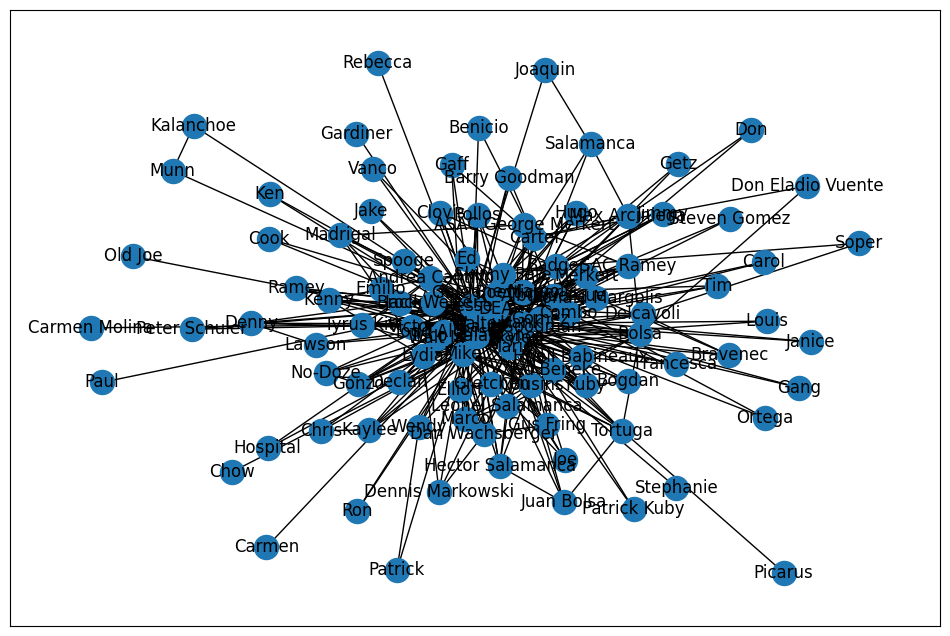

In [186]:
plt.figure(figsize=(12, 8)) #Создаёт холст размером 12×8 дюймов для визуализации.
pos = nx.spring_layout(G, seed=0) #Вычисляет координаты (x, y) для каждого узла на плоскости, используя алгоритм пружинной раскладки
#layout - это словарь вершин с их координтами. Создаем layout(расположение) по созданному узлу G ПО ТИПУ spring_layout
nx.draw_networkx(G, pos=pos) #рисует граф на текущей фигуре (plt.figure), используя заданные позиции pos
# Т.е pos - задал координаты В РАСПОЛОЖЕНИИ spring_layout, draw_networkx - построй сеть G с расположением из pos(координатами)

Let's try to modify the visalization. For example, we may want to shrink the size and font of the not popular characters.

Not everythong can be passed to `draw_networkx`, but there are other functions.

To draw nodes and their labels:
* `draw_networkx_nodes` - Specify colors, edge colors, sizes, etc. for nodes
* `draw_networkx_labels` - Specify font color, size, etc for labels of nodes

To draw edges and their labels
* `draw_networkx_edges` - Specify colors, edge colors, sizes, styles etc. for edges
* `draw_networkx_edge_labels` - Specify font color, size, etc for labels of nodes

Узлы с высокой степенью (или суммарным весом рёбер) → большие, жирный шрифт.

Узлы с низкой степенью → маленькие, мелкий шрифт.


Some example: (The network will look bad:) )

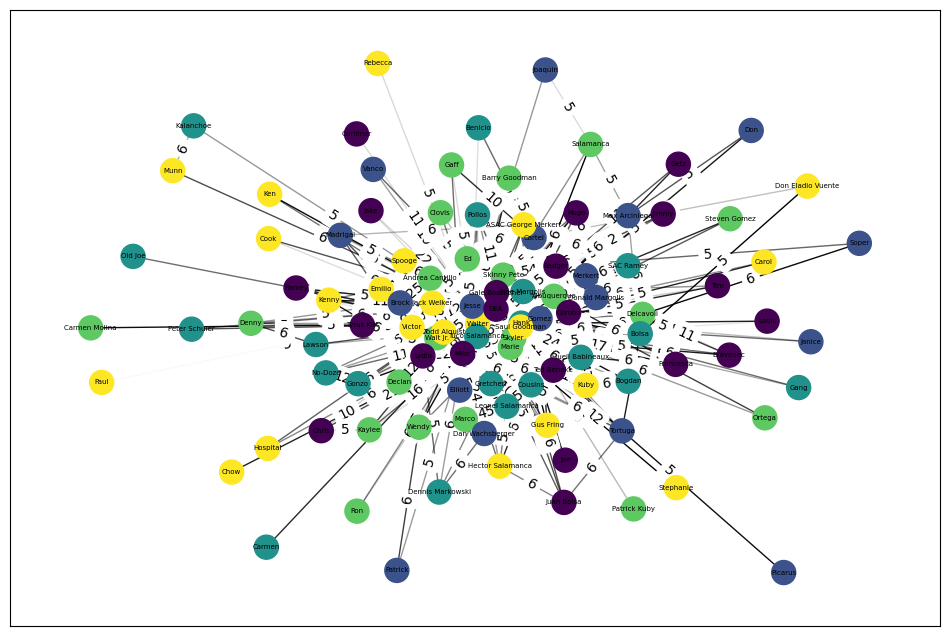

In [187]:
plt.figure(figsize=(12, 8)) #Создаёт холст размером 12×8 дюймов для визуализации.

#Let's try to modify the visalization. For example, we may want to shrink the size and font of the not popular characters.
# pos - задал координаты В РАСПОЛОЖЕНИИ spring_layout
#Every node has some random color
nx.draw_networkx_nodes(G, pos=pos, node_color=np.random.randint(5, size=len(G)))
#Set the same font size for all nodes
nx.draw_networkx_labels(G, pos=pos, font_size=5)
#Every edge has some random transparisy level
nx.draw_networkx_edges(G, pos=pos, alpha=np.random.rand(len(G)))
#The label of every edge is its weight (подписать каждое ребро его весом)
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=nx.get_edge_attributes(G, 'weight'));

# Task 1 (3 points) Network visualization

## Layout (расположение вершин в графе)

The center of the plot containt too many nodes - let's change layout a bit: start with `nx.spring_layout(G, seed=0)`, and change positions of the nodes in the following way:



1.   Put $Walter$ (main character of the series) in (0, 0)
2.   Move all nodes correspondingly (if $Walter$ was in position (1, 2) and $Jesse$ was in position(7, 7), $Jesse$ should be moved to position (6, 5))
3.  Multiply position of nodes by $c(node, Walter)$, where

$$c(node, Walter)  = \exp\left(-\frac{d(node, Walter)^2}{2\sigma^2}\right)$$

$d(node, Walter)$ - Euclidean distance between $node$ and $Walter$



In [188]:
#A layout(расположение вершин в графе)  - словарь с позициями вершин
# {0: array([0.19888598, 0.46741317]),
# 1: array([0.38149045, 0.7270436 ]),
# 2: array([0.16994327, 0.29379077]),

def Walter_layout(G, sigma):
    # сначала делаем обычную раскладку (получаем начальные позиции из spring_layout каждой вершины БЕЗ рандома при каждом запуске)
    pos = nx.spring_layout(G, seed=0)

    # запоминаем, где сидит Волтер
    walter_x, walter_y = pos['Walter']

    # двигаем всех так, чтобы Волтер оказался в (0, 0) - прост смещение координат всех на него
    for node in pos: #делаем переьор каждой вершины
        x, y = pos[node] #находим ее координаты
        pos[node] = [x - walter_x, y - walter_y] #когда перебор дойдет до Волтера, он сдвинется в 0

    # для каждого узла считаем коэффициент и умножаем его позицию
    for node in pos:
        x, y = pos[node]
        # евклидово расстояние от Волтера (он в 0,0)
        d = (x**2 + y**2)**0.5
        # коэффициент по формуле
        c = np.exp(-d**2 / (2 * sigma**2))
        # меняем позицию
        pos[node] = [x * c, y * c]

    # на всякий случай принудительно ставим Волтера в центр
    pos['Walter'] = [0.0, 0.0]

    return pos
    return pos

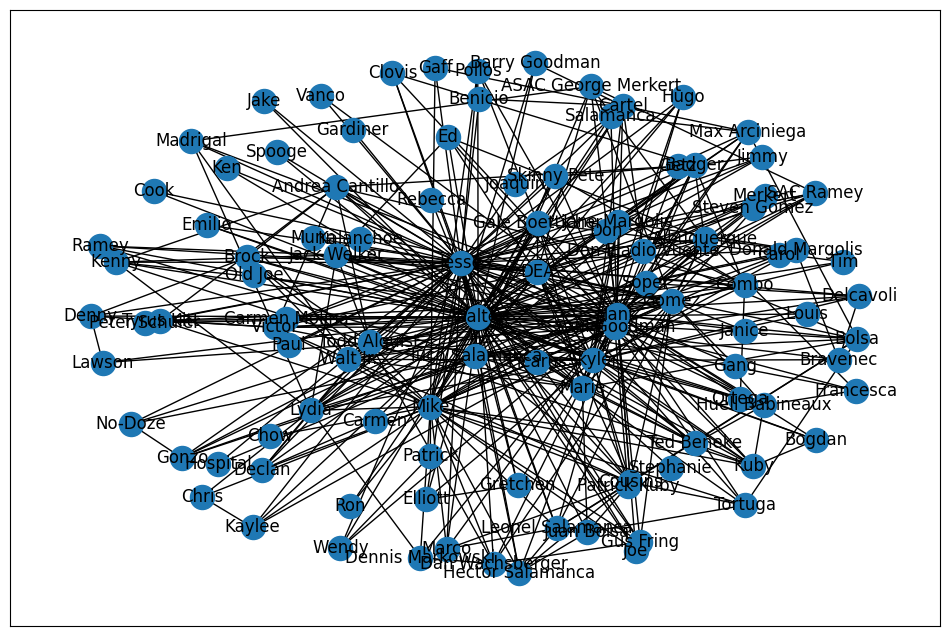

In [189]:
plt.figure(figsize=(12, 8)) #Создаёт холст размером 12×8 дюймов для визуализации.
pos = Walter_layout(G, 0.5) #получаем новые координаты узлов: Волтер в центре, остальные сжаты по формуле ОТ НЕГО
assert type(pos) == dict #pos должен быть словарём {узел: [x, y]} => cм. комент выше по представлению Layout
assert np.allclose(pos['Walter'], 0) #волт в 0
assert np.allclose(pos['Jesse'], [-0.01324671,  0.06392936]) #джесси тут

nx.draw_networkx(G, pos=pos) # нарисуй граф G, ГДЕ pos - задал координаты В РАСПОЛОЖЕНИИ spring_layout (измененные)

## Labels of nodes

Let's try to pretify the lebels of nodes(Определить границы узлов). Write a function that takes the network and positions of nodes(layot задал их координаты) and return a dictionary with the network, position of nodes, text and font size of labels.

If the character's degree is 5 or less, their label should not be written.

2 characters with the maximum degree should have font size = 10 (5 for others)

In [190]:
def network_labels_params(G, pos):
  #The following code was generated by QwenChat https://chat.qwen.ai/ (ТОЛЬКО КОМЕНТЫ И ОПТИМИЗАЦИЯ КОДА!)
    # ------------------------------------------------------------
    # ШАГ 1: УЗНАЕМ, СКОЛЬКО СВЯЗЕЙ У КАЖДОГО ПЕРСОНАЖА (его "степень")
    # ------------------------------------------------------------
    # G.degree() — это специальная функция NetworkX, которая считает, сколько рёбер выходит из каждого узла (т.е. сколько связей у персонажа).
    # dict(...) превращает результат в обычный словарь.
    # Пример того, что получится:
    # deg = {'Walter': 15, 'Jesse': 12, 'Skyler': 8, 'DEA': 3, ...}
    deg = dict(G.degree())

    # ------------------------------------------------------------
    # ШАГ 2: НАХОДИМ ДВА САМЫХ ПОПУЛЯРНЫХ ПЕРСОНАЖА
    # ------------------------------------------------------------
    # deg.values() — это список всех чисел-степеней: [15, 12, 8, 3, ...]
    # sorted(..., reverse=True) — сортирует их от большего к меньшему: [15, 12, 8, ...]
    # [:2] — берём первые два элемента → самые большие степени
    # top2 будет списком из двух чисел, например: [15, 12]
    top2 = sorted(deg.values(), reverse=True)[:2]

    # ------------------------------------------------------------
    # ШАГ 3: СОЗДАЁМ ПУСТЫЕ СЛОВАРИ ДЛЯ ОТВЕТА
    # ------------------------------------------------------------
    # labels — сюда мы запишем, какие персонажи вообще должны иметь подпись.
    # Формат: { 'Имя': 'Имя' } — просто чтобы знать, кто попал в список.
    labels = {}

    # font_size — сюда запишем, какого размера шрифт использовать для каждого персонажа.
    # Формат: { 'Имя': 10 } или { 'Имя': 5 }
    font_size = {}

    # ------------------------------------------------------------
    # ШАГ 4: ПРОХОДИМ ПО ВСЕМ ПЕРСОНАЖАМ И РЕШАЕМ, ЧТО С НИМИ ДЕЛАТЬ
    # ------------------------------------------------------------
    # G.nodes() — список всех персонажей в графе: ['Walter', 'Jesse', 'DEA', ...]
    for node in G.nodes():
        # d — это число, сколько связей у текущего персонажа (например, 15 у Walter)
        d = deg[node]

        if d <= 5:
            continue

        # --------------------------------------------------------
        # ЕСЛИ СЮДА ДОШЛИ — ЗНАЧИТ, У ПЕРСОНАЖА БОЛЬШЕ 5 СВЯЗЕЙ → НУЖНА МЕТКА
        # --------------------------------------------------------
        # Добавляем его в словарь labels.
        # Ключ — имя персонажа, значение — тоже имя (просто чтобы он был в списке).
        # Пример: labels['Walter'] = 'Walter'
        labels[node] = node

        # --------------------------------------------------------
        # ТЕПЕРЬ РЕШАЕМ, КАКОГО РАЗМЕРА ШРИФТ ИСПОЛЬЗОВАТЬ
        # --------------------------------------------------------
        # Если степень этого персонажа равна первой или второй максимальной —
        # значит, он один из двух самых популярных → шрифт = 10
        if d == top2[0] or d == top2[1]:
            fs = 10
        else:
            # Иначе — обычный шрифт = 5
            fs = 5

        # Записываем размер шрифта в словарь font_size
        # Пример: font_size['Walter'] = 10
        font_size[node] = fs

    # ------------------------------------------------------------
    # ШАГ 5: ВОЗВРАЩАЕМ ВСЁ, ЧТО ПРОСИЛИ
    # ------------------------------------------------------------
    # Нужно вернуть словарь с четырьмя ключами:
    # - 'G': сам граф (просто передаём дальше)
    # - 'pos': координаты узлов (тоже передаём как есть)
    # - 'labels': словарь с именами тех, у кого будет метка
    # - 'font_size': словарь с размерами шрифта для этих же имён
    return {
        'G': G,
        'pos': pos,
        'labels': labels,
        'font_size': font_size
    }

In [191]:

G.edges

EdgeView([('Walter', 'Albuquerque'), ('Walter', 'Skyler'), ('Walter', 'Walt Jr.'), ('Walter', 'Hank'), ('Walter', 'Bogdan'), ('Walter', 'Steven Gomez'), ('Walter', 'Cook'), ('Walter', 'Jesse'), ('Walter', 'Gomez'), ('Walter', 'Emilio'), ('Walter', 'Marie'), ('Walter', 'DEA'), ('Walter', 'Ken'), ('Walter', 'Combo'), ('Walter', 'Delcavoli'), ('Walter', 'Jake'), ('Walter', 'Elliott'), ('Walter', 'Gretchen'), ('Walter', 'Badger'), ('Walter', 'Hugo'), ('Walter', 'Tuco Salamanca'), ('Walter', 'Skinny Pete'), ('Walter', 'No-Doze'), ('Walter', 'Gonzo'), ('Walter', 'Louis'), ('Walter', 'Clovis'), ('Walter', 'Carmen Molina'), ('Walter', 'Spooge'), ('Walter', 'Jane Margolis'), ('Walter', 'Saul Goodman'), ('Walter', 'Jimmy'), ('Walter', 'Denny'), ('Walter', 'Tortuga'), ('Walter', 'Ted Beneke'), ('Walter', 'Bravenec'), ('Walter', 'Gus Fring'), ('Walter', 'Donald Margolis'), ('Walter', 'Mike'), ('Walter', 'Cousins'), ('Walter', 'Leonel Salamanca'), ('Walter', 'Marco'), ('Walter', 'Bolsa'), ('Walter'

In [192]:
params_labels = network_labels_params(G, pos)
assert params_labels.keys() == set(['G', 'pos', 'labels', 'font_size']) #убедиться, что в ответе ровно эти 4 ключа и никаких лишних.
assert len(params_labels['labels']) == len(params_labels['font_size']) == 45 #количество персонажей, у которых есть метка (labels),
# должно быть равно количеству записей в font_size,
assert params_labels['font_size']['Walt Jr.'] == params_labels['font_size']['DEA'] == params_labels['font_size']['Andrea Cantillo'] == 5
assert list(params_labels['font_size'].values()).count(10) == 2 #среди всех значений размеров шрифта должно быть ровно два случая с размером 10.
assert list(params_labels['font_size'].values()).count(5) == len(params_labels['font_size']) - 2

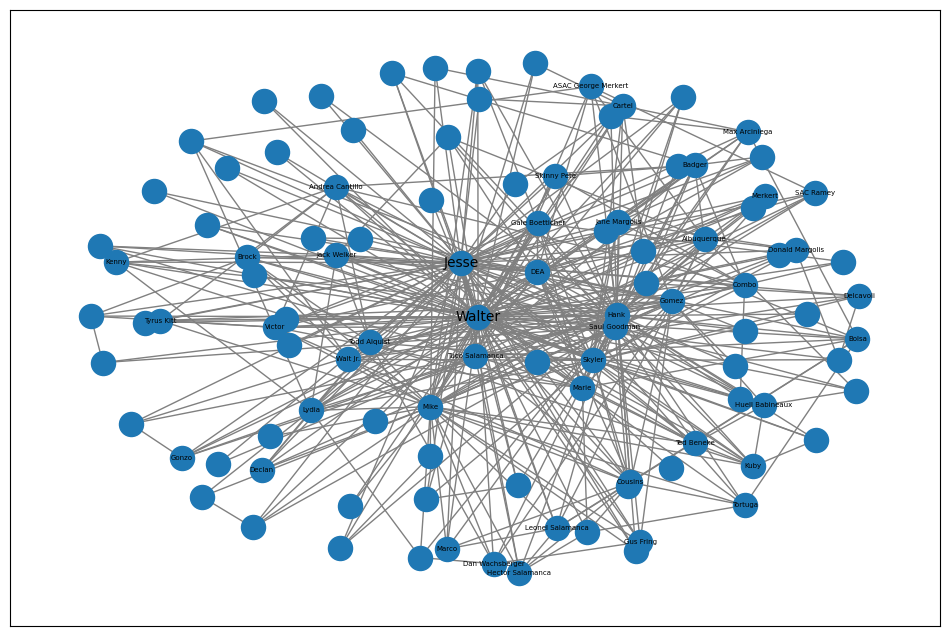

In [193]:
plt.figure(figsize=(12, 8))

nx.draw_networkx_nodes(G, pos=pos) #Рисуем все узлы (кружочки) графа G в тех позициях, которые заданы в словаре pos.

nx.draw_networkx_labels(**params_labels)
nx.draw_networkx_edges(G, pos=pos, edge_color='grey') #Рисуем все рёбра серым цветом, чтобы они не отвлекали от узлов и подписей.

## Nodes

Write a function, that takes the network and positions of nodes and return a dictionary with the network, position of nodes, their colors and sizes.

The size of the node should correspond to the degree:

$$\text{size} = \text{degree}^{1.5} + 100$$

The color of the node should correspond to the length of the shortest path to Walter



In [194]:
def network_nodes_params(G, pos):
    node_size = [] #будем складывать степень каждого узла (модиф по формуле)

    # размеры узлов (node_size) — зависят от степени
    # цвета узлов (node_color) — зависят от расстояния до Уолтера


    # 1) подсчет размера узлов
    for node in G.nodes(): #перебор узлов в порядке из G.nodes()
        deg = G.degree(node)
        # размер ушла по формуле: size = degree**1.5 + 100
        size = deg ** 1.5 + 100
        # добавляем это число в список => т.е просто сформировали список из модиф-ых степеней для каждого узла
        node_size.append(size)

    # 2) подсчет цвета
    # nx.shortest_path_length(G, source='Walter') — возвращает словарь:
    # {'Walter': 0, 'Jesse': 1, 'DEA': 2, ...}
    distances = dict(nx.shortest_path_length(G, source='Walter'))

    # список цветов - по одному на каждый узел (ЗАВИСИТ ОТ РАССТОЯНИЯ ДО УОЛТЕРА!)
    node_color = []


    for node in G.nodes(): #перебор узлов в порядке из G.nodes()
        d = distances[node]  #для каждого узла находим расстояние до Уолтера (любое число: 0, 2, 100...)
        # это число и будет цветом (в matplotlib цвета можно задавать числами)
        node_color.append(d) #=> просто список целых чисел

    return {
        'G': G,               # исходный граф
        'pos': pos,           # переданные координаты
        'node_size': node_size,   # список размеров (по одному на узел)
        'node_color': node_color  # список цветов (по одному на узел)
    }

In [195]:
params_nodes = network_nodes_params(G, pos)

assert set(params_nodes.keys()) == {'G', 'node_color', 'node_size', 'pos'}
assert np.allclose(params_nodes['node_size'][:3], [762.5526394181824, 152.38320341483518, 281.01933598375615])
assert np.all(np.unique(params_nodes['node_color']) == np.array([0,1,2]))
assert params_nodes['node_color'][0] == 0

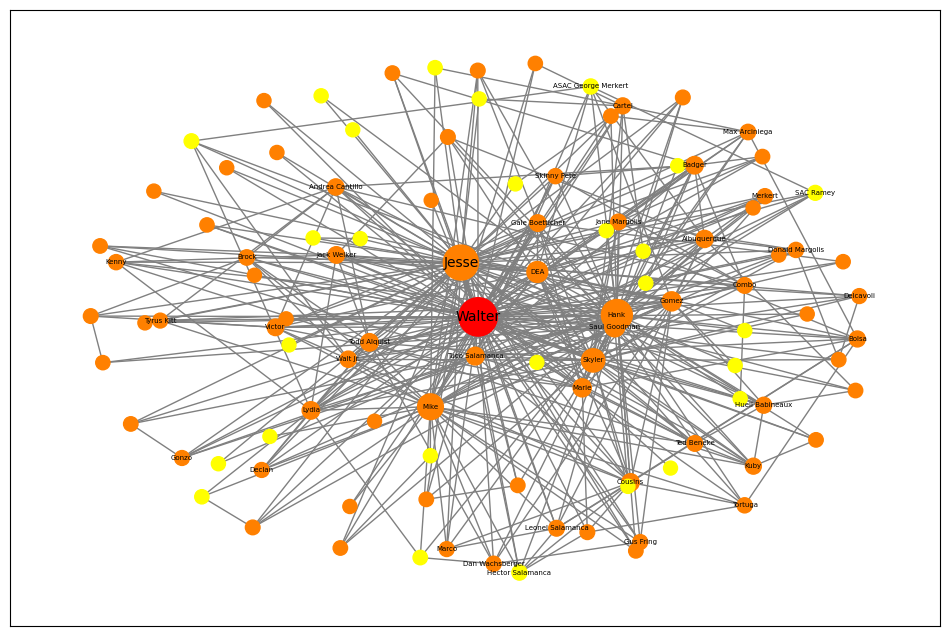

In [196]:
plt.figure(figsize=(12, 8))

nx.draw_networkx_nodes(**params_nodes, cmap='autumn')
nx.draw_networkx_labels(**params_labels)
nx.draw_networkx_edges(G, pos=pos, edge_color='grey')

## Edges

Time to work with edges. Each edge has an attribute `weight`, let's use it as `alpha`. For all the edge (except the one with the biggest weight) alpha should be a linear transformation of the weight: for the edge with second biggest weight it should be 1, for the smallest weight = 0.1. The edge of the biggest weigth should also have `alpha`= 1

And the colors of all edges (except for the one with the biggest weight) should be black. Edge with the biggest weight should be another color.

In [197]:
def network_edge_params(G, pos):

    # 1) вытягиваем все веса из словаря
    weights = [] #просто список из весов в каждом ребре
    # G.edges(data=True) даёт тройки: (узел1, узел2, атрибуты)
    for u, v, data in G.edges(data=True): #проходим по всем ребрам графа
        w = data['weight']      # достаём число из словаря
        weights.append(w)       # добавляем вес в список

    weights = np.array(weights) #для удобства чтения в вектор


    # 2) находим веса макс и предмакс и минимальный вес

    unique_weights = np.unique(weights) #выбираем уникальные (без повторов чтоб)
    unique_weights_sorted = np.sort(unique_weights) #сортим по ВОЗРАСТАНИЮ!!

    max_weight = unique_weights_sorted[-1] #т.к сорт был по ВОЗРАСТАНИЮ

    # если есть хотя бы два разных веса, то второй по величине — предпоследний
    if len(unique_weights_sorted) >= 2:
        second_max = unique_weights_sorted[-2]

    min_weight = unique_weights_sorted[0] # самый мал - первый в отсорт списке



    # 3) меняем вес (прозрачность) для каждого ребра
    alpha = []  # значения прозрачности

    for w in weights: #перебор каждого веса в списке
        if w == max_weight or w == second_max: #если он макс или пред макс = 1
            alpha.append(1.0)
        else:
          # для остальных - делаем прозрачность между 0.1 и 1.0
          # чем ближе вес к min_weight — тем ближе alpha к 0.1
          # чем ближе к second_max — тем ближе к 1.0

          a = 0.1 + (w - min_weight) * (1.0 - 0.1) / (second_max - min_weight)
          # Ограничиваем значение, чтобы не выйти за рамки
          if a < 0.1:
            a = 0.1
          if a > 1.0:
            a = 1.0
          alpha.append(a)

    alpha = np.array(alpha)

    # 4) задем цвет ребер
    # ------------------------------------------------------------
    edge_color = []  # сюда будем класть цвет каждого ребра

    for w in weights:
        if w == max_weight:
            # самое тяжёлое ребро — красное
            edge_color.append('red')
        else:
            # остальные — чёрные
            edge_color.append('black')

    return {
        'G': G,               # исходный граф
        'pos': pos,           # переданные координаты
        'alpha': alpha,       # массив прозрачностей (обязательно np.array!)
        'edge_color': edge_color  # список цветов
    }

In [198]:
params_edges = network_edge_params(G, pos)

assert set(params_edges.keys()) == {'G', 'alpha', 'pos', 'edge_color'}
assert np.allclose(params_edges['alpha'][:4], np.array([0.14061758, 1.        , 0.18978622, 0.85142518]))
assert np.min(params_edges['alpha']) == 0.1
assert np.max(params_edges['alpha']) == 1.0
assert (params_edges['alpha'] == 1.0).sum() == 2
assert (params_edges['alpha'] > 1.0).sum() == 0
assert params_edges['edge_color'][7] != params_edges['edge_color'][0]
assert np.sum(np.array(params_edges['edge_color']) == params_edges['edge_color'][0]) == len(G.edges)-1

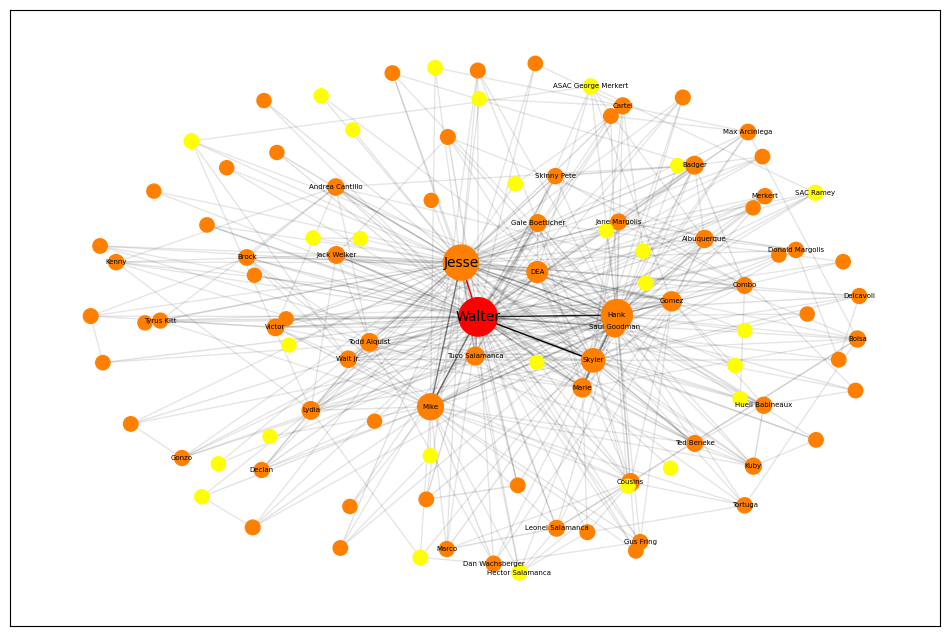

In [199]:
plt.figure(figsize=(12, 8))

nx.draw_networkx_nodes(**params_nodes, cmap='autumn')
nx.draw_networkx_labels(**params_labels)
nx.draw_networkx_edges(**params_edges)

# Task 2 (3 points) Power law

### MLE with friendship paradox based sampling

Friendship paradox: on average, the number of friends of a random friend is always greater than the number of friends of a random individual.

Formally:

$v$ - random node of the network

$u$ - end-node of a random edge of the network,

then

$\mathbf{E}[k(u)] \ge \mathbf{E}[k(v)]$

Let's try another method of estimating $\alpha, x_{min}$: MLE with friendship paradox based sampling.

Algorithm:

1. Sample t end-nodes of the network ($u_1, ..., u_t$)

2. Compute $x_{min}$ based on the sampled nodes

3. Compute $\alpha$:

$$\hat{\alpha} = \frac{t}{\sum_{i=1}^t \ln \frac{k(u_i)}{x_{min}}}+2$$

4. Repet the steps `steps` times, return mean result

In [200]:
def mle_friendship_paradox_power_law_alpha(G, t=100, n_steps=1000):
    #The following code was generated by QwenChat https://chat.qwen.ai/
    """
    Оценивает параметр alpha степенного закона P(k) ~ k^(-alpha)
    с помощью выборки, основанной на ПАРАДОКСЕ ДРУЖБЫ.

    🔍 ТЕОРИЯ:
    - В реальных сетях (соцсети, интернет) распределение степеней часто следует степенному закону.
    - Прямая оценка alpha по всем узлам может быть неточной, потому что "хвост" (редкие хабы) плохо представлен.
    - Парадокс дружбы говорит: "если выбрать случайного друга, у него в среднем больше друзей, чем у случайного человека".
    - Это происходит потому, что хабы участвуют в большем числе рёбер → они чаще попадаются при выборке через рёбра.
    - Поэтому, если мы будем выбирать узлы НЕ напрямую, а как концы случайных рёбер,
      мы получим выборку, обогащённую хабами — и сможем точнее оценить "хвост" распределения.
    """

    # ШАГ 1: ПОДГОТОВКА — получаем список всех рёбер один раз
    # ------------------------------------------------------------
    # G.edges() — это объект NetworkX, который содержит все рёбра в виде кортежей: (узел1, узел2).П: [(u1, v1), (u2, v2), ...]
    # Преобразуем его в обычный список, чтобы можно было делать random.choice
    edges_list = list(G.edges())

    # Если в графе вообще нет рёбер (например, изолированные узлы), то степенной закон не определён.
    # Возвращаем типичное значение для BA-графа: alpha = 3
    if not edges_list:
        return 3.0

    # ШАГ 2: ПРЕДВЫЧИСЛЯЕМ СТЕПЕНИ ВСЕХ УЗЛОВ
    # ------------------------------------------------------------
    # G.degree() — даёт объект, похожий на словарь: {узел: степень}
    # Сохраняем его как настоящий словарь, чтобы быстро получать степень любого узла за O(1)
    degree_dict = dict(G.degree())

    # => т.е получили список пар ребер + словарь вершина и степень

    # Список, куда будем складывать оценки alpha на каждом шаге
    # Потом усредним их — это уменьшит шум и даст более стабильный результат.
    alphas = []

    # ШАГ 3: ПОВТОРЯЕМ ЭКСПЕРИМЕНТ n_steps РАЗ = 1000
    # ------------------------------------------------------------
    # Каждый "шаг" — это независимая выборка из t узлов = 100 (1000 раз будем пикать 100 вершин)
    for _ in range(n_steps):

        # Список для хранения степеней выбранных "случайных друзей"
        sampled_degrees = []

        # Делаем t выборок "случайных друзей" = 100
        for _ in range(t):
            # random.choice(edges_list) — выбирает одно случайное ребро, например: ('Walter', 'Jesse')
            # random.choice(этого_ребра) — выбирает один из двух узлов: либо 'Walter', либо 'Jesse'
            # Это и есть "случайный друг" — конец случайного ребра.
            u = random.choice(random.choice(edges_list))

            # Берём степень этого узла из предвычисленного словаря
            k_u = degree_dict[u]

            # Запоминаем её
            sampled_degrees.append(k_u)

        # Теперь у нас есть t степеней, полученных через парадокс дружбы.
        # Эта выборка смещена в сторону узлов с высокой степенью — именно то, что нужно для оценки хвоста.

        # ШАГ 4: ОПРЕДЕЛЯЕМ x_min — начало степенного закона
        # ------------------------------------------------------------
        # x_min — это минимальная степень, с которой начинается "чистый" степенной закон.
        # В идеале его подбирают сложными методами, но здесь берём просто минимальное значение в выборке.
        x_min = min(sampled_degrees)

        # Защита от вырожденных случаев: степень не может быть меньше 1
        if x_min < 1:
            x_min = 1

        # ШАГ 5: ВЫЧИСЛЯЕМ СУММУ ЛОГАРИФМОВ ДЛЯ ФОРМУЛЫ MLE
        # ------------------------------------------------------------
        # 📌 КЛЮЧЕВАЯ ТЕОРИЯ:
        # При выборке через рёбра (парадокс дружбы) распределение степеней становится:
        #   P_edge(k) ∝ k * P(k) ∝ k * k^(-alpha) = k^(-(alpha - 1))
        # То есть мы наблюдаем степенной закон с показателем (alpha - 1).
        #
        # Следовательно, если применить обычную MLE-формулу к этой выборке,
        # мы получим оценку для (alpha - 1), а не для alpha.
        #
        # Обычная MLE: (alpha - 1) = 1 + t / sum(ln(k_i / x_min))
        # Отсюда: alpha = 2 + t / sum(ln(k_i / x_min))
        #
        # Поэтому в формуле стоит "+2", а не "+1"!

        log_sum = sum(np.log(k / x_min) for k in sampled_degrees if k >= x_min)

        # ШАГ 6: ВЫЧИСЛЯЕМ ОЦЕНКУ alpha И СОХРАНЯЕМ ЕЁ
        # ------------------------------------------------------------
        # Защита от деления на ноль:
        # Если все k_i == x_min, то log_sum = 0 → деление невозможно.
        # В реальных сетях такого почти не бывает, но на всякий случай проверяем.
        if log_sum > 0:
            # ВАЖНО: +2, потому что выборка смещённая!
            alpha_hat = 2 + t / log_sum
            alphas.append(alpha_hat)

    # ШАГ 7: ВОЗВРАЩАЕМ СРЕДНЕЕ ПО ВСЕМ ШАГАМ
    # ------------------------------------------------------------
    # Усреднение по многим запускам делает оценку более надёжной.
    if len(alphas) == 0:
        # Если все шаги были пропущены (крайне маловероятно), возвращаем типичное значение
        return 3.0

    return np.mean(alphas)

In [201]:
#Checking Pref attachment - powerlaw with alpha = 3
assert np.abs(mle_friendship_paradox_power_law_alpha(nx.barabasi_albert_graph(1000, 5, seed=0)) - 3) < 0.1
assert np.abs(mle_friendship_paradox_power_law_alpha(nx.barabasi_albert_graph(5000, 5, seed=0)) - 3) < 0.1

alpha = mle_friendship_paradox_power_law_alpha(G)
assert np.abs(alpha - 2.41) < 0.5

### Q-Q plot

 Q–Q (quantile–quantile) plot is  a graphical method for comparing two probability distributions by plotting their quantiles against each other.

 The function takes graph (which degree distribution we will use) and `x_min, alpha` - hyperparameters of power law - let's compare the quantiles 0, 0.01, 0.02, ..., 0.99 of the theoretical distribution (powerlaw with given parameters) and empirical (calculated using the provided data).

 The function should return 2 numpy arranys - theoretical and empirical quantiles.

In [202]:
def q_q_data(G, alpha, x_min):

    # строит Q-Q plot для сравнения: эмп. расп-ия графа и теор. расп-ия степенного закона с параметрами alpha и x_min
    # если два распределения совпадают, точки лежат на диагонали y = x (если отклонения - смотреть ком. ниже после кода)

    # 1) строим имп. расп - ие (по степеням узлов)

    # формируем список из ВСЕХ степеней узлов графа
    degrees = [d for n, d in G.degree()] # метод G.degree() возвращает (узел, степень). П: [('A', 2), ('B', 1)] - выбираем ток степень

    # степенной закон определён только для k >= x_min
    empirical_degrees = [k for k in degrees if k >= x_min]

    # сортим эмп. квантили (чтобы построить рас-ие)
    empirical_degrees.sort()

    # 2) находим теор. квантили
    # сначала расчетрим уровни квантиля на про-ве
    quantile_levels = np.linspace(0, 0.99, 100)  # 100 точек: 0.00, 0.01, ..., 0.99

    # для непрерывного степенного закона квантильная функция:
    #   Q(p) = x_min / (1 - p)^(1/(alpha - 1))
    # Где p — уровень квантиля (от 0 до 1)
    theoretical_quantiles = x_min / np.power(1 - quantile_levels, 1 / (alpha - 1))

    # 3) считаем эмп квантили => В numpy это делает функция np.quantile
    empirical_quantiles = np.quantile(empirical_degrees, quantile_levels, method='linear')

    return theoretical_quantiles, empirical_quantiles

Text(0, 0.5, 'Empirical quantiles')

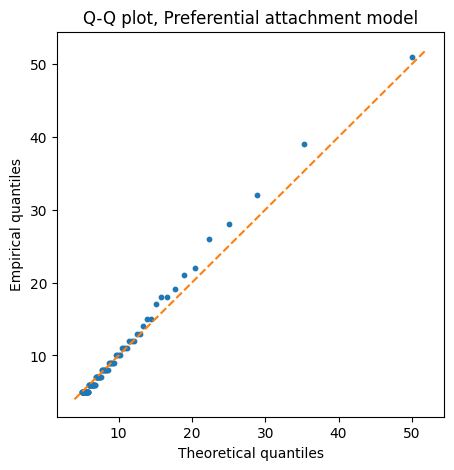

In [203]:
#Checking Pref attachment - powerlaw with alpha = 3, x_min = m
t, e = q_q_data(nx.barabasi_albert_graph(1000, m=5, seed=0), 3, 5)
assert len(t) == len(e) == 100
assert t[0] == e[0] == 5.0
assert np.all(t[:-1]<=t[1:])
assert np.all(e[:-1]<=e[1:])

fig = plt.figure(figsize=(5, 5))
plt.scatter(t, e, s=10)
plt.plot([min(t.min(), e.min()) - 1, max(t.max(), e.max()) + 1], [min(t.min(), e.min()) - 1,  max(t.max(), e.max()) + 1], '--', c='tab:orange')
plt.title('Q-Q plot, Preferential attachment model')
plt.xlabel('Theoretical quantiles')
plt.ylabel('Empirical quantiles')

левый нижний угол: Эмпирические квантили < теоретических
.То есть: в реальном графе меньше узлов с очень малой степенью, чем предсказывает модель(теоретический степенной закон предсказывает больше узлов с k=5,6,7, чем есть на самом деле)

правый верхний угол: Эмпирические квантили > теоретических
.То есть: в реальном графе есть узлы с ещё более высокой степенью, чем предсказывает степенной закон. П: Теоретический 99%-й квантиль = 48 → эмпирический 99%-й квантиль = 51 → точка (48, 51) выше диагонали.(Распределение смещено вправо)

Т.Е ЕСЛИ Все точки выше диагонали ->
Эмпирическое распределение «тяжелee» — больше больших значений (тяжёлый хвост)
П: Допустим, у вас есть:

Теоретическое распределение (степенной закон):
→ 25%-й квантиль = 10
→ Это значит: по модели, 25% узлов имеют степень ≤ 10.

Эмпирическое распределение (ваши данные):
→ 25%-й квантиль = 15
→ Это значит: в реальности, 25% узлов имеют степень ≤ 15.

Точка на Q–Q plot: (10, 15) → выше диагонали. => Чтобы накопить 25% узлов, в реальных данных нужно дойти до более высокой степени (15), чем предсказывает модель (10).

Text(0, 0.5, 'Empirical quantiles')

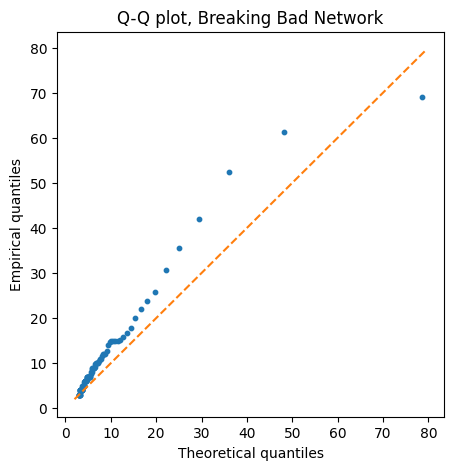

In [204]:
t, e = q_q_data(G, 2.41, 3)
assert len(t) == len(e) == 100
assert np.all(t[:-1]<=t[1:])
assert np.all(e[:-1]<=e[1:])

fig = plt.figure(figsize=(5, 5))
plt.scatter(t, e, s=10)
plt.plot([min(t.min(), e.min()) - 1, max(t.max(), e.max()) + 1], [min(t.min(), e.min()) - 1,  max(t.max(), e.max()) + 1], '--', c='tab:orange')
plt.title('Q-Q plot, Breaking Bad Network')
plt.xlabel('Theoretical quantiles')
plt.ylabel('Empirical quantiles')

Т.Е ЕСЛИ Все точки выше диагонали -> Эмпирическое распределение «тяжелee» — больше больших значений (тяжёлый хвост)

ИТОГО:

Для малых степеней (левая часть графика):
Эмпирических узлов с очень малой степенью меньше, чем предсказывает степенной закон (потому что многие персонажи всё же имеют ≥3 связи).
→ точки ниже диагонали.

Для больших степеней (правая часть):
Узлы с высокой степенью (Walter, Jesse) слишком популярны по сравнению с тем, что предсказывает степенной закон с
α = 2.41

То есть: в реальности есть сильнее выраженные хабы, чем в чистом степенном законе.
→ точки выше диагонали.

# Task 3. (4 points) Watts–Strogatz model

Watts–Strogatz model is graph generation model that produces small-world graph. It tackles problem of low clustering coefficent in Erdős–Rényi model.

Small-world graph is a graph with high clustering and low distances: $⟨L⟩ ∝ ln (n)$ (distance between random 2 nodes is proportional to the logarithm of number on nodes).

Hyperparameters of Watts–Strogatz model:

$n$ - number of nodes

$k$ - starting degree of every node (even number)

$p$ - probability to rewire an edge

Algorithm of Watts–Strogatz model:



1.   Construct ring lttice graph with hyperparameters $n,k$ (see next task)
2.   For every node $v$ investigate the edges to the right neighbors ($u_1, ..., u_{k/2}$):

2. Rrewire the edge with probability $p$: delete edge $(v, u_i)$ and add edge $(v, s)$, where s is a random node (but no self loops or edge duplication)

суть => В модели Эрдёша–Реньи рёбра случайны, поэтому между любыми узлами быстро находятся короткие пути — среднее расстояние растёт как
ln n.

В кольцевой решётке узлы соединены только с ближайшими соседями, поэтому чтобы добраться до удалённого узла, нужно пройти почти весь граф — расстояние растёт как n.
Именно поэтому ER — «малый мир», а решётка — нет.



## Ring lattice

Ring lattice is graph with $n$ nodes, if they are in circular layout each node will be connected to $k/2$ left and $k/2$ right nodes next to it.

For example, ring lattice with $n=10$ nd $k=4$:

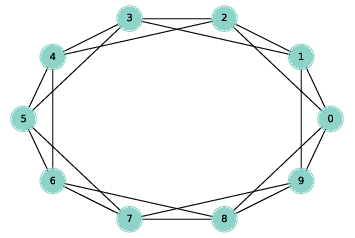

Write a function that generates such graph, nodes need to be labelled $0, 1, ..., n-1$. Assume $k$ is even.

In [205]:
def ring_lattice_graph(n, k):
    # граф из n узлов, расположенных по окружности гдее каждый узел соединен с k/2 ближайшими соседями
    G = nx.Graph() # создаем пустой НЕОРИЕНТ граф
    G.add_nodes_from(range(n)) # добавляем узлы с метками 0 - n-1

    for v in range(n): #для каждого узла из графа
        for i in range(1, k // 2 + 1):  #перебор всех правых соседей (1ый, 2ой и тд)
            u = (v + i) % n # % n чтобы завернуть число обратно в круг
            G.add_edge(v, u)
    return G




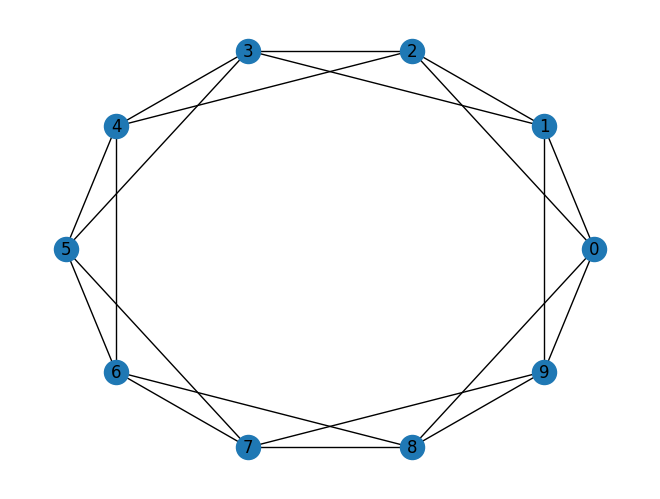

In [206]:
assert nx.degree_histogram(ring_lattice_graph(10, 4))[4] == 10
assert nx.degree_histogram(ring_lattice_graph(20, 4))[4] == 20
assert nx.degree_histogram(ring_lattice_graph(10, 2))[2] == 10
assert nx.degree_histogram(ring_lattice_graph(20, 2))[2] == 20

nx.draw_circular(ring_lattice_graph(10, 4), with_labels=True)

## Rewire

Now, we need a function that rewires the edge. It takes nodes $v$ (current node) and $u$ (right neighbor) and the graph and rewire the edge to another randomly chosen (no duplicating, self-loops) node.

The function should change the given graph, not copy it.


In [207]:
def rewire(G, v, u):

    # ПЕРЕПОДКЛЮЧЕНИЕ: удаляет ребро (v, u) - соседа справа в графе и выбирает случайный узел s (v, u) (подключается к нему)

    # 1) удаляем исходное ребро (v, u)
    G.remove_edge(v, u)

    forbidden = {v, u}  # запрещённые узлы: сам v и старый сосед u
    forbidden.update(G.neighbors(v))  # добавляем всех текущих соседей v

    # ==> находим все разрешённые узлы для подключения (без запрещенок)
    all_nodes = set(G.nodes())
    allowed_targets = list(all_nodes - forbidden)

    # 2) выбираем рандомный разрешённый узел
    s = random.choice(allowed_targets)

    # 3) добавляем его к графу
    G.add_edge(v, s)

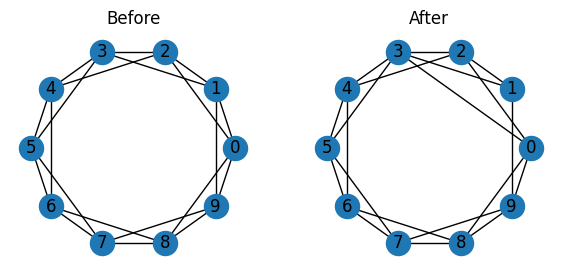

In [208]:
g = nx.Graph([(0,1), (1,2)])
rewire(g, 0, 1)
assert set(list(g.edges)) == {(0, 2), (1, 2)}

fig, axs=plt.subplots(ncols=2, figsize=(7, 3))
g = ring_lattice_graph(10, 4)
nx.draw_circular(g, with_labels=True, ax=axs[0])
axs[0].set_title('Before')
rewire(g, 0, 1)
axs[1].set_title('After')
nx.draw_circular(g, with_labels=True, ax=axs[1])

## Model

Now, let's implement the model.

Function takes $n, k, p$, buildes ring lattice and with probability $p$ rewires right neighbours (for node 5 with neighbours 3, 4, 6, 7 we will try to rewire only 6 and 7; for node 9 with neighbors 7, 8, 0, 1 - only 0, 1)

In [209]:
def watts_strogatz_graph(n, k, p):

    #алго: 1) строим кольцевую решётку (ring lattice) с параметрами n , k и p - вер-ть ПЕРЕПОДКЛЮЧЕНИЯ РЕБРА!!
    # 2) Для каждого узла v - смотрим соседей + удаляем (v, u) с веро-ть р и заменяем его на (v, s)

    #1) создаём кольцевую решётку
    G = ring_lattice_graph(n, k)

    #2) переподключаем правых соседей (код из пред. блока)
    for v in range(n): #для каждого узлла в графе
        right_neighbors = [] #добавляем онли правых соседей
        for i in range(1, k // 2 + 1):
            u = (v + i) % n
            right_neighbors.append(u)

        # для каждого правого соседа пробуем переподключить ребро с р
        for u in right_neighbors:
            if random.random() < p:
                rewire(G, v, u)  # эта функция уже написана и изменяет G

    return G

In [210]:
grid = [[10, 4, 0.1],
        [10, 4, 0.9],
         [100, 8, 0.01],
         [100, 8, 0.5],
         [100, 8, 0.99]]
for n, k, p in grid:
    w = watts_strogatz_graph(n, k, p)
    assert len(w.nodes) == n
    assert len(w.edges) == int(k / 2 * n)
    degree_seq = np.array([w.degree[i] for i in w.nodes])
    w_nx = nx.watts_strogatz_graph(n, k, p, seed=0)
    degree_seq_nx = np.array([w_nx.degree[i] for i in w_nx.nodes])
    assert ks_2samp(degree_seq, degree_seq_nx).pvalue > 0.05

Let's look on results with different $p$:

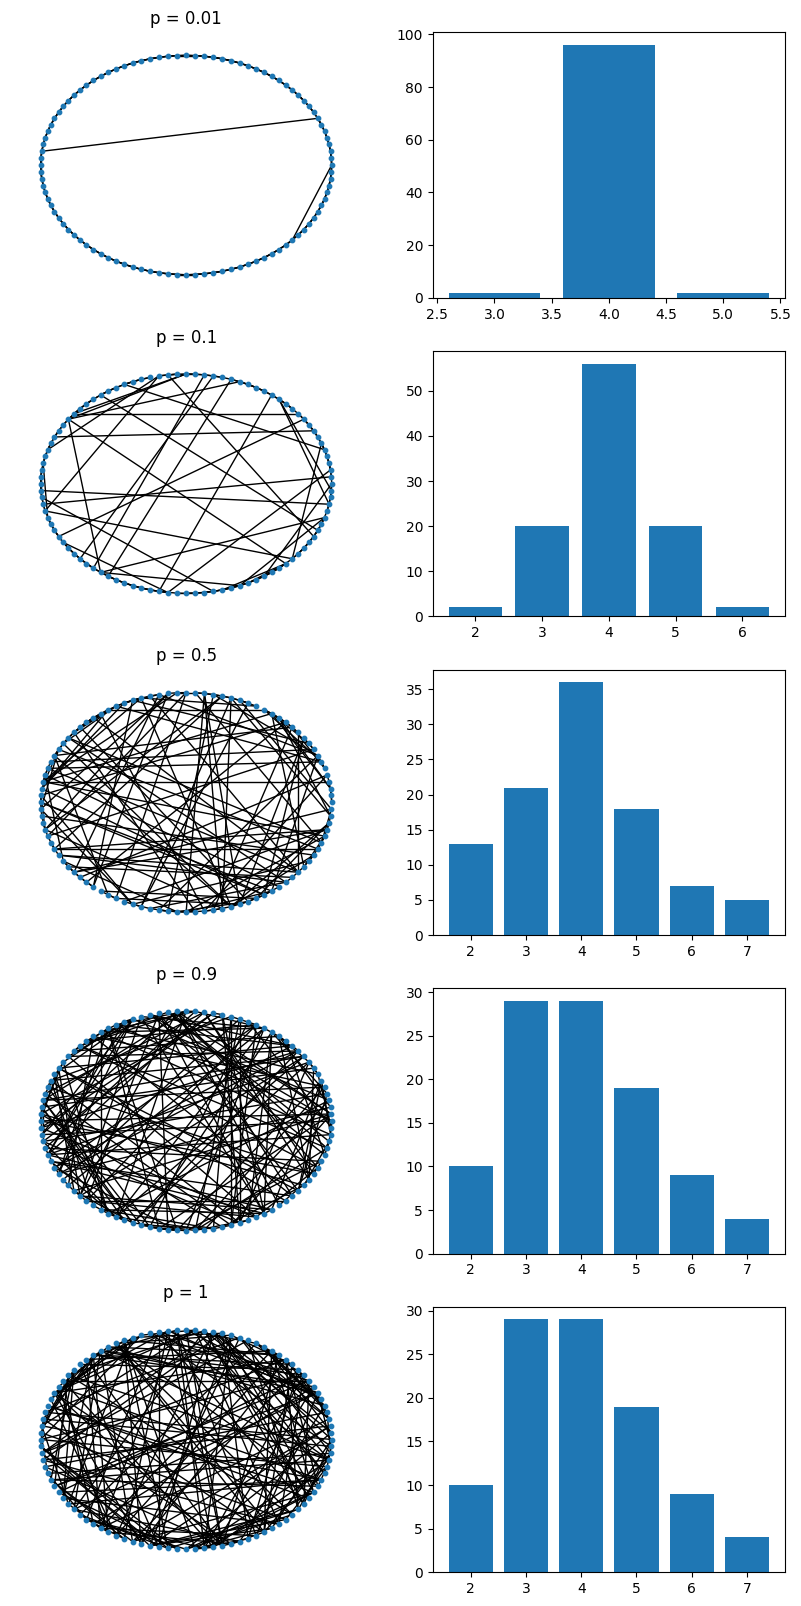

In [211]:
fig, axs = plt.subplots(figsize=(10, 20), ncols=2, nrows=5)

for ii, p in enumerate([0.01, 0.1, 0.5, 0.9, 1]):
  w = watts_strogatz_graph(100, 4, p)

  nx.draw_circular(w, ax=axs[ii][0], node_size=10)
  axs[ii][0].set_title('p = ' +str(p))
  bins, freq = np.unique(np.array([w.degree[i] for i in w.nodes]), return_counts=True)
  axs[ii][1].bar(bins, freq)

## Clustering coefficient and Average path length

Let's check how average clustering coefficient (local) and average shortest path length depend on $p$.

Write function that for every $p$ given in `p_list` will generate 100 Watts–Strogatz graphs, compute average of the characteristics. The function should return 2 numpy arrays.

If graph is not connected, skip it.

In [212]:
def clustering_and_path_lengths(n, k, p_list):
    #The following code was generated WITH HELP of QwenChat https://chat.qwen.ai/
    """
    Для каждого значения p из p_list:
    - Генерирует 100 графов Уоттса–Строгаца,
    - Вычисляет средний кластеризационный коэффициент и среднюю длину кратчайшего пути,
    - Пропускает несвязные графы,
    - Возвращает усреднённые значения по 100 (или меньше) графам.

    Возвращает:
    - avg_cl: массив средних кластеризаций для каждого p,
    - avg_paths_length: массив средних длин путей для каждого p.
    """

    # Списки для хранения результатов по каждому p
    avg_cl = []
    avg_paths_length = []

    # Обрабатываем каждый p из списка
    for p in p_list:
        cl_list = []      # кластеризации для этого p
        path_list = []    # длины путей для этого p

        # Генерируем 100 графов
        for _ in range(100):
            # Создаём граф Уоттса–Строгаца
            G = watts_strogatz_graph(n, k, p)

            # Проверяем, связный ли граф
            if not nx.is_connected(G):
                continue  # пропускаем несвязные графы

            # Вычисляем средний локальный кластеризационный коэффициент
            # (усреднение по всем узлам)
            cl = nx.average_clustering(G)
            cl_list.append(cl)

            # Вычисляем среднюю длину кратчайшего пути
            # (усреднение по всем парам узлов)
            path_len = nx.average_shortest_path_length(G)
            path_list.append(path_len)

        # Усредняем по всем успешным графам (для данного p)
        if cl_list:  # если есть хотя бы один связный граф
            avg_cl.append(np.mean(cl_list))
            avg_paths_length.append(np.mean(path_list))
        else:
            # На всякий случай (если все графы несвязные)
            avg_cl.append(np.nan)
            avg_paths_length.append(np.nan)

    # Преобразуем в numpy массивы и возвращаем
    return np.array(avg_cl), np.array(avg_paths_length)

In [213]:
avg_cl, avg_paths_length = clustering_and_path_lengths(10, 2, [0, 0.5, 1])
assert len(avg_cl) == len(avg_paths_length) == 3
assert np.allclose(avg_cl[0], 0)
assert np.allclose(avg_paths_length[0], 2.77777778)

Переподключение рёбер разрушает локальные треугольники → кластеризация падает.

При большем k соседи узла сами становятся "ближе" друг к другу —
потому что в решётке они тоже соединены с k/2 соседями.
→ Возникает плотная локальная структура → больше треугольников → выше кластеризация.

Кластеризация растёт с k, потому что:
При большем k соседи узла расположены ближе друг к другу в решётке,
А значит, они сами соединены рёбрами,
→ Число реальных связей между соседями растёт быстрее, чем число возможных пар,
→ Доля (кластеризация) увеличивается.==> чем больше соседей(рост к), тем меньше длина пути между вершинами

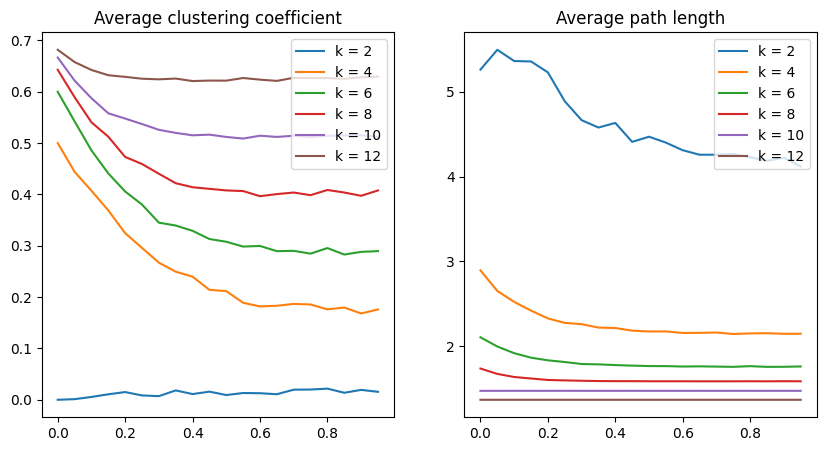

In [214]:
fig, axs = plt.subplots(figsize=(10, 5), ncols=2)
p_list = np.arange(0, 1, 0.05)

for k in range(2, 14, 2):
  avg_cl, avg_paths_length = clustering_and_path_lengths(20, k, p_list)

  axs[0].plot(p_list, avg_cl, label='k = ' +str(k))
  axs[0].set_title('Average clustering coefficient')
  axs[0].legend(loc='upper right')

  axs[1].plot(p_list, avg_paths_length, label='k = ' +str(k))
  axs[1].set_title('Average path length')
  axs[1].legend(loc='upper right')